# 11 · Large-amplitude oscillatory shear (LAOS)

Small oscillations probe a material without disturbing it; large ones deform it the way processing and use
do - spreading a cream, chewing a yoghurt. The response is no longer sinusoidal, and $G'$ and $G''$ alone
cannot describe it. LAOS analysis extracts the extra information from the **shape** of the stress signal:
Fourier harmonics, Lissajous curves and the Chebyshev decomposition.

**What you will learn**
- describe nonlinear oscillatory responses with Lissajous curves and Fourier harmonics
- compute and interpret the Chebyshev measures G'_M, G'_L, S and T
- distinguish intra-cycle stiffening from overall softening

**Before you start:** notebooks 08 and 10; Fourier series  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, laos, oscillatory, constitutive as cm
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Lissajous curves of a polymer solution (Giesekus model)

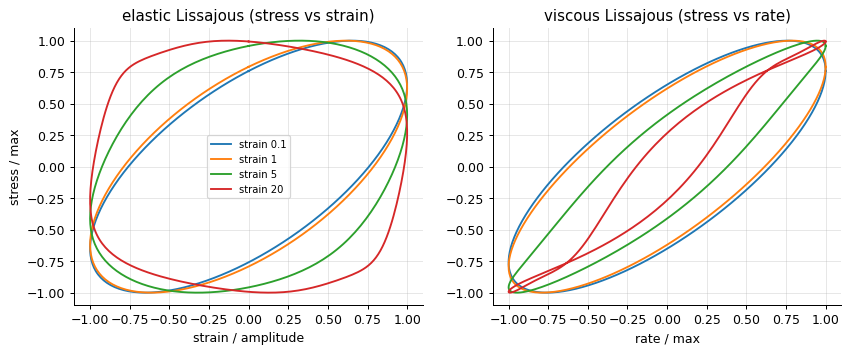

relative third harmonic I3/I1: {0.1: 0.0, 1.0: 0.0033, 5.0: 0.0445, 20.0: 0.1245}


In [2]:
modes = cm.modes_from_spectrum([60.0, 25.0, 8.0], [0.02, 0.2, 2.0], "giesekus", alpha=0.25)
w = 2.0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
I3 = {}
for g0 in (0.1, 1.0, 5.0, 20.0):
    r = cm.laos_shear(modes, g0, w, n_cycles=12)
    s = r["stress"]
    a1.plot(r["strain"] / g0, s / np.abs(s).max(), label=f"strain {g0:g}")
    a2.plot(g0 * w * np.cos(w * r["t"]) / (g0 * w), s / np.abs(s).max())
    I3[g0] = laos.harmonics(r["t"][:-1], r["strain"][:-1], s[:-1], w)["I3_I1"]
a1.set(xlabel="strain / amplitude", ylabel="stress / max", title="elastic Lissajous (stress vs strain)"); a1.legend(fontsize=8)
a2.set(xlabel="rate / max", title="viscous Lissajous (stress vs rate)"); plt.show()
print("relative third harmonic I3/I1:", {k: round(v, 4) for k, v in I3.items()})

At small amplitude the elastic Lissajous curve is an ellipse (linear response). At large amplitude it
distorts: the stress no longer follows the strain sinusoidally, and higher harmonics appear. The relative
third harmonic $I_3/I_1$ grows with the square of the amplitude at first and is the most common single measure
of nonlinearity.

## A stirred yoghurt

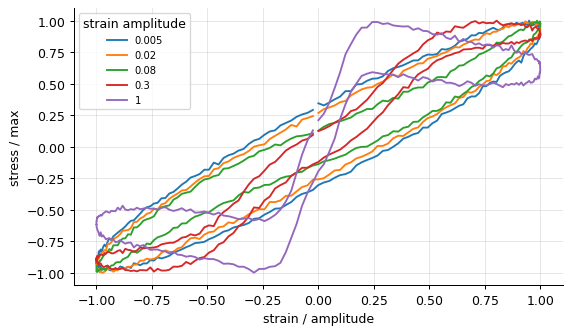

 strain_amp  G'_M (Pa)  G'_L (Pa)      S      T  I3/I1
      0.005    307.984    300.113 -0.026 -0.093  0.006
      0.020    303.848    311.633  0.025 -0.219  0.013
      0.080    304.039    432.424  0.297 -0.522  0.073
      0.300    352.177    291.870 -0.207 -0.848  0.162
      1.000    467.706     72.598 -5.442 -1.264  0.385


In [3]:
yo = pd.read_csv(datasets.path("yoghurt_laos.csv"), comment="#")
w_y = 2 * np.pi
rows = []
fig, ax = plt.subplots()
for g0, grp in yo.groupby("strain_amplitude"):
    c = laos.chebyshev(grp.time_s, grp.strain, grp.shear_stress_Pa, w_y)
    rows.append((g0, c["G_M"], c["G_L"], c["S"], c["T"], c["I3_I1"]))
    ax.plot(grp.strain / g0, grp.shear_stress_Pa / grp.shear_stress_Pa.abs().max(), label=f"{g0:g}")
ax.set(xlabel="strain / amplitude", ylabel="stress / max"); ax.legend(title="strain amplitude", fontsize=8); plt.show()
print(pd.DataFrame(rows, columns=["strain_amp", "G'_M (Pa)", "G'_L (Pa)", "S", "T", "I3/I1"]).round(3).to_string(index=False))

Read the table from small to large amplitude. At the smallest strain $G'_M$ and $G'_L$ agree: linear response.
At intermediate strains the large-strain modulus exceeds the minimum-strain modulus ($S > 0$): the network
**stiffens within each cycle** as its strands are stretched. At larger strains the sign reverses: the
large-strain modulus falls far below its linear value while the minimum-strain modulus stays high - within
each cycle the gel is stiff near zero strain but yields at the extremes ($S$ strongly negative). The
first-harmonic $G'$ alone would report only a gradual softening; the Chebyshev measures resolve stiffening
and then yielding, which is closer to what the mouth feels. The viscous measure $T$ is negative throughout:
the flow contribution thins within each cycle.

## Inside the algorithm: harmonics by least squares
Over one steady cycle, fit the stress with $\sin n\omega t$ and $\cos n\omega t$ for odd $n$; the coefficients divided by the
strain amplitude are $G'_n$ and $G''_n$:

In [4]:
g0, grp = list(yo.groupby("strain_amplitude"))[3]
tt, s = grp.time_s.to_numpy(), grp.shear_stress_Pa.to_numpy()
X = np.column_stack([f(n * w_y * tt) for n in (1, 3, 5) for f in (np.sin, np.cos)])
c = np.linalg.lstsq(X, s, rcond=None)[0] / g0
lib = laos.harmonics(tt, grp.strain, s, w_y, n_max=5)
print("by hand G'_1, G'_3:", np.round(c[[0, 2]], 3), " library:", np.round(lib["Gp"][:2], 3))

by hand G'_1, G'_3: [347.918  56.766]  library: [347.918  56.766]


## Exercises
1. Simulate LAOS of the UCM model (the same spectrum, no Giesekus term) at strain 20. How large is $I_3/I_1$, and why is the UCM shear stress linear in strain at any amplitude?
2. For the yoghurt, at which strain amplitude does $G'_L$ fall below half of its small-strain value? Compare with the flow point from the first-harmonic moduli (`oscillatory.moduli_from_waveforms` for each amplitude).
3. **Implement it yourself:** the area of the elastic Lissajous loop equals the energy dissipated per cycle, $\pi\gamma_0^2 G''_1$. Compute the loop area of one yoghurt cycle with the shoelace formula and compare.